In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

Форма изображения: (675, 1200) | тип данных: uint8
Мин. яркость: 0 | макс. яркость: 255 | средняя яркость: 78.24


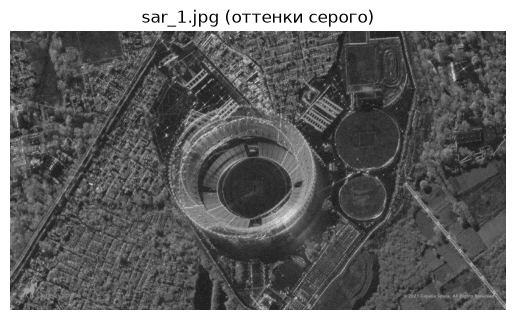

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print('Форма изображения:', image_gray.shape, '| тип данных:', image_gray.dtype)
print('Мин. яркость:', image_gray.min(), '| макс. яркость:', image_gray.max(),
      '| средняя яркость:', round(image_gray.mean(), 2))

plt.imshow(image_gray, cmap='gray')
plt.title('sar_1.jpg (оттенки серого)')
plt.axis('off')
plt.show()

## Шум
Гауссов ($\mu=0$, $\sigma=25$) и постоянный $U[-50, 50]$ — дисперсия примерно одна и та же. Шум генерирую во float и прибавляю к float-копии изображения, иначе в uint8 отрицательная половина шума обрежется.

In [3]:
mean = 0
stddev = 25
noise_gauss = np.random.normal(mean, stddev, image_gray.shape).astype(np.float32)

# прибавляем шум к float-копии и обрезаем результат в [0, 255]
image_noise_gauss = np.clip(image_gray.astype(np.float32) + noise_gauss, 0, 255).astype(np.uint8)

mse_noise_gauss = mean_squared_error(image_gray, image_noise_gauss)
ssim_noise_gauss = structural_similarity(image_gray, image_noise_gauss)
print('Шум Гаусса (sigma = %d): MSE = %.1f, SSIM = %.4f' % (stddev, mse_noise_gauss, ssim_noise_gauss))

Шум Гаусса (sigma = 25): MSE = 610.2, SSIM = 0.4810


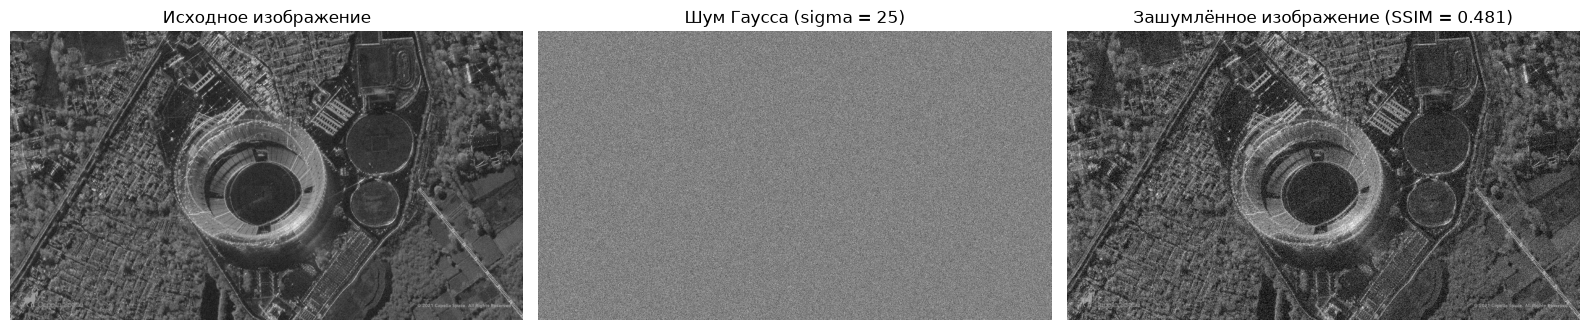

In [4]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noise_gauss, cmap='gray')
plt.title('Шум Гаусса (sigma = 25)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_noise_gauss, cmap='gray')
plt.title('Зашумлённое изображение (SSIM = %.3f)' % ssim_noise_gauss)
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
a, b = -50, 50
noise_unif = np.random.uniform(a, b, image_gray.shape).astype(np.float32)

# прибавляем к float-копии и обрезаем в [0, 255]
image_noise_unif = np.clip(image_gray.astype(np.float32) + noise_unif, 0, 255).astype(np.uint8)

mse_noise_unif = mean_squared_error(image_gray, image_noise_unif)
ssim_noise_unif = structural_similarity(image_gray, image_noise_unif)
print('Постоянный шум (U[%d, %d]): MSE = %.1f, SSIM = %.4f' % (a, b, mse_noise_unif, ssim_noise_unif))

Постоянный шум (U[-50, 50]): MSE = 823.0, SSIM = 0.4154


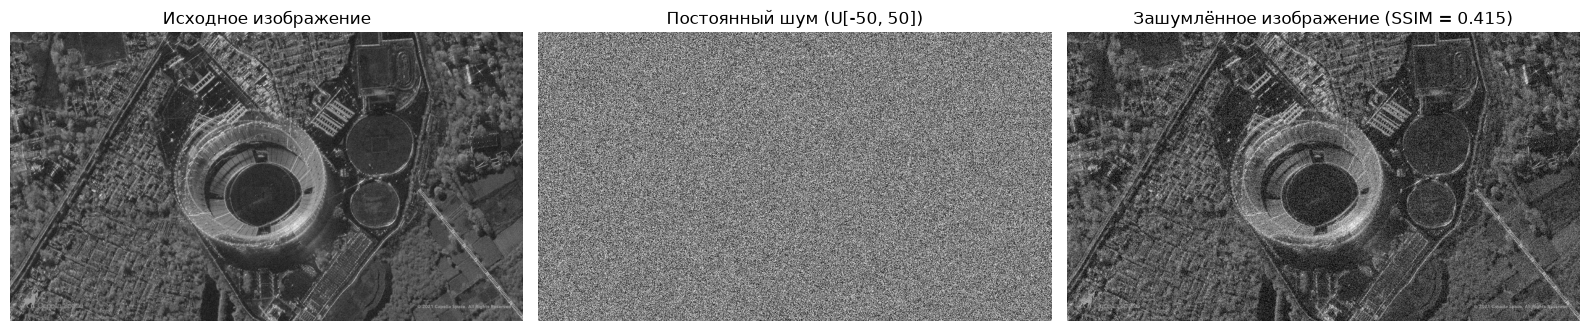

In [6]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noise_unif, cmap='gray')
plt.title('Постоянный шум (U[-50, 50])')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_noise_unif, cmap='gray')
plt.title('Зашумлённое изображение (SSIM = %.3f)' % ssim_noise_unif)
plt.axis('off')

plt.tight_layout()
plt.show()

## Медианный фильтр

In [7]:
results = []   # (тип шума, фильтр, MSE, SSIM)
images = {}

def add_result(noise_name, filter_name, img_filtered):
    mse = mean_squared_error(image_gray, img_filtered)
    ssim = structural_similarity(image_gray, img_filtered)
    results.append((noise_name, filter_name, mse, ssim))
    images[(noise_name, filter_name)] = img_filtered
    print('%-15s | %-32s MSE = %7.1f  SSIM = %.4f' % (noise_name, filter_name, mse, ssim))

def plot_grid(res_gauss, res_unif, suptitle):
    names = list(res_gauss.keys())
    plt.figure(figsize=(4 * len(names), 7.5))
    for row, (res, noise_name) in enumerate([(res_gauss, 'Шум Гаусса'), (res_unif, 'Постоянный шум')]):
        for col, name in enumerate(names):
            img = res[name]
            mse = mean_squared_error(image_gray, img)
            ssim = structural_similarity(image_gray, img)
            plt.subplot(2, len(names), row * len(names) + col + 1)
            plt.imshow(img, cmap='gray')
            plt.title('%s\n%s: MSE = %.0f, SSIM = %.3f' % (noise_name, name, mse, ssim), fontsize=9)
            plt.axis('off')
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


In [8]:
median_gauss = {}
median_unif = {}

for k in [3, 5, 7, 9]:
    median_gauss['k = %d' % k] = cv2.medianBlur(image_noise_gauss, k)
    median_unif['k = %d' % k] = cv2.medianBlur(image_noise_unif, k)

for name, res in median_gauss.items():
    add_result('Шум Гаусса', 'Медианный (%s)' % name, res)
for name, res in median_unif.items():
    add_result('Постоянный шум', 'Медианный (%s)' % name, res)

Шум Гаусса      | Медианный (k = 3)                MSE =   210.6  SSIM = 0.6364
Шум Гаусса      | Медианный (k = 5)                MSE =   240.5  SSIM = 0.5603


Шум Гаусса      | Медианный (k = 7)                MSE =   286.0  SSIM = 0.4819
Шум Гаусса      | Медианный (k = 9)                MSE =   331.2  SSIM = 0.4142
Постоянный шум  | Медианный (k = 3)                MSE =   311.0  SSIM = 0.5431


Постоянный шум  | Медианный (k = 5)                MSE =   283.2  SSIM = 0.5102
Постоянный шум  | Медианный (k = 7)                MSE =   309.4  SSIM = 0.4544


Постоянный шум  | Медианный (k = 9)                MSE =   346.1  SSIM = 0.3975


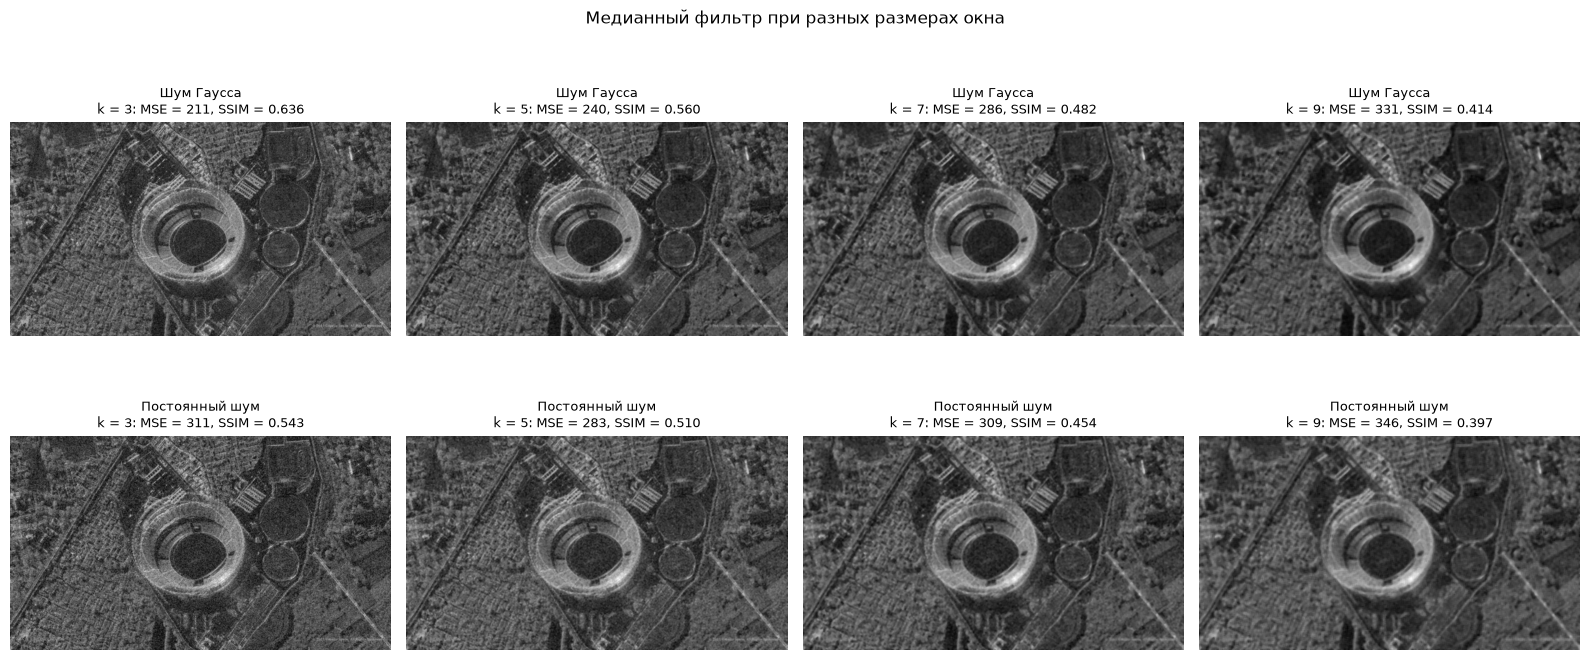

In [9]:
plot_grid(median_gauss, median_unif, 'Медианный фильтр при разных размерах окна')

## Фильтр Гаусса

In [10]:
gauss_gauss = {}
gauss_unif = {}

for k in [3, 5, 7, 9]:
    gauss_gauss['k = %d' % k] = cv2.GaussianBlur(image_noise_gauss, (k, k), 0)
    gauss_unif['k = %d' % k] = cv2.GaussianBlur(image_noise_unif, (k, k), 0)

for name, res in gauss_gauss.items():
    add_result('Шум Гаусса', 'Фильтр Гаусса (%s)' % name, res)
for name, res in gauss_unif.items():
    add_result('Постоянный шум', 'Фильтр Гаусса (%s)' % name, res)

Шум Гаусса      | Фильтр Гаусса (k = 3)            MSE =   150.3  SSIM = 0.7239
Шум Гаусса      | Фильтр Гаусса (k = 5)            MSE =   156.8  SSIM = 0.7061
Шум Гаусса      | Фильтр Гаусса (k = 7)            MSE =   189.0  SSIM = 0.6477


Шум Гаусса      | Фильтр Гаусса (k = 9)            MSE =   214.8  SSIM = 0.6017
Постоянный шум  | Фильтр Гаусса (k = 3)            MSE =   180.2  SSIM = 0.6856
Постоянный шум  | Фильтр Гаусса (k = 5)            MSE =   172.5  SSIM = 0.6831


Постоянный шум  | Фильтр Гаусса (k = 7)            MSE =   197.1  SSIM = 0.6362
Постоянный шум  | Фильтр Гаусса (k = 9)            MSE =   220.2  SSIM = 0.5948


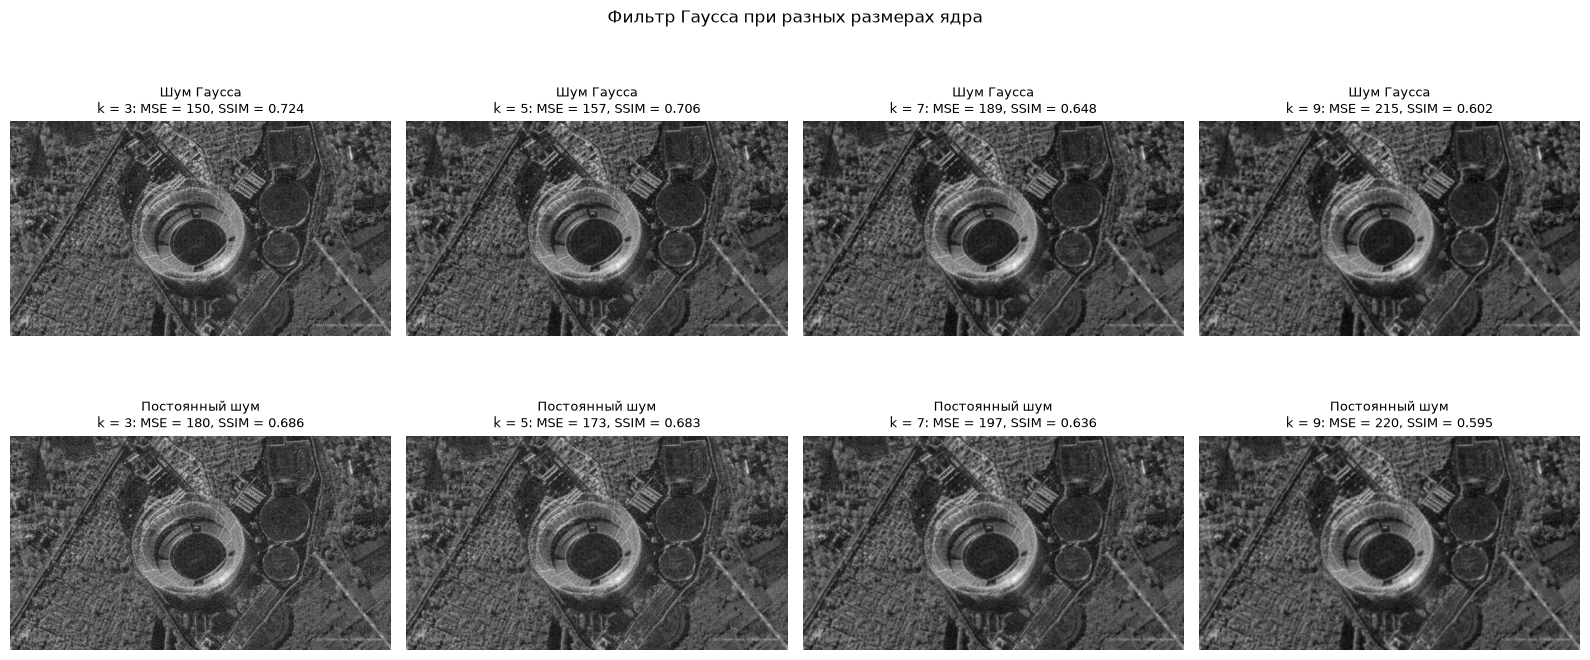

In [11]:
plot_grid(gauss_gauss, gauss_unif, 'Фильтр Гаусса при разных размерах ядра')

## Билатериальный фильтр

In [12]:
bilat_gauss = {}
bilat_unif = {}

bilat_params = [(5, 25, 25), (5, 50, 50), (9, 75, 75), (9, 150, 150)]
for d, sigma_color, sigma_space in bilat_params:
    name = 'd = %d, sigma = %d' % (d, sigma_color)
    bilat_gauss[name] = cv2.bilateralFilter(image_noise_gauss, d, sigma_color, sigma_space)
    bilat_unif[name] = cv2.bilateralFilter(image_noise_unif, d, sigma_color, sigma_space)

for name, res in bilat_gauss.items():
    add_result('Шум Гаусса', 'Билатериальный (%s)' % name, res)
for name, res in bilat_unif.items():
    add_result('Постоянный шум', 'Билатериальный (%s)' % name, res)

Шум Гаусса      | Билатериальный (d = 5, sigma = 25) MSE =   302.9  SSIM = 0.6031
Шум Гаусса      | Билатериальный (d = 5, sigma = 50) MSE =   163.0  SSIM = 0.7034
Шум Гаусса      | Билатериальный (d = 9, sigma = 75) MSE =   202.1  SSIM = 0.6124


Шум Гаусса      | Билатериальный (d = 9, sigma = 150) MSE =   253.3  SSIM = 0.5279
Постоянный шум  | Билатериальный (d = 5, sigma = 25) MSE =   478.4  SSIM = 0.5058
Постоянный шум  | Билатериальный (d = 5, sigma = 50) MSE =   220.5  SSIM = 0.6433


Постоянный шум  | Билатериальный (d = 9, sigma = 75) MSE =   209.0  SSIM = 0.6101
Постоянный шум  | Билатериальный (d = 9, sigma = 150) MSE =   254.3  SSIM = 0.5305


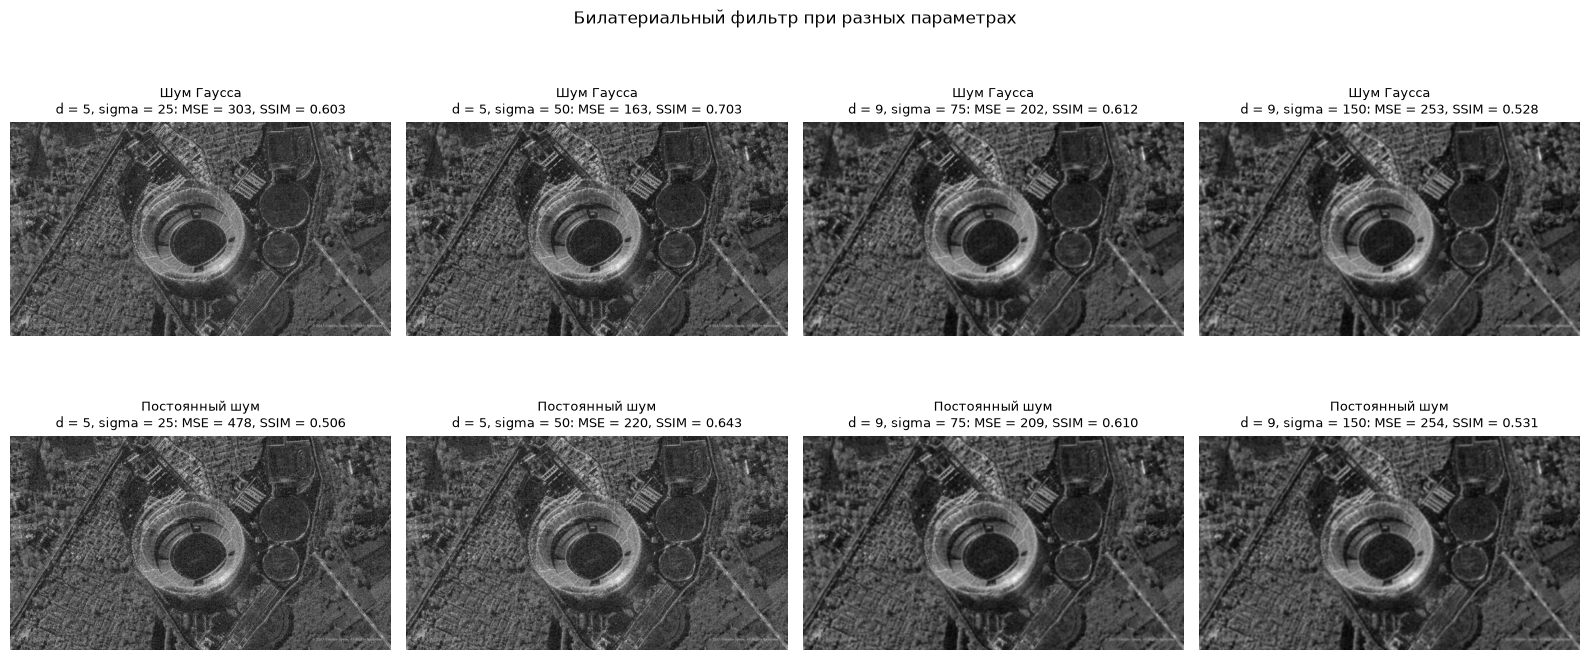

In [13]:
plot_grid(bilat_gauss, bilat_unif, 'Билатериальный фильтр при разных параметрах')

## Нелокальные средние

In [14]:
nlm_gauss = {}
nlm_unif = {}

for h in [10, 15, 20, 30]:
    nlm_gauss['h = %d' % h] = cv2.fastNlMeansDenoising(image_noise_gauss, None, h)
    nlm_unif['h = %d' % h] = cv2.fastNlMeansDenoising(image_noise_unif, None, h)

for name, res in nlm_gauss.items():
    add_result('Шум Гаусса', 'Нелокальных средних (%s)' % name, res)
for name, res in nlm_unif.items():
    add_result('Постоянный шум', 'Нелокальных средних (%s)' % name, res)

Шум Гаусса      | Нелокальных средних (h = 10)     MSE =   610.1  SSIM = 0.4810
Шум Гаусса      | Нелокальных средних (h = 15)     MSE =   420.5  SSIM = 0.5592
Шум Гаусса      | Нелокальных средних (h = 20)     MSE =   181.4  SSIM = 0.6659


Шум Гаусса      | Нелокальных средних (h = 30)     MSE =   259.5  SSIM = 0.5052
Постоянный шум  | Нелокальных средних (h = 10)     MSE =   823.0  SSIM = 0.4154
Постоянный шум  | Нелокальных средних (h = 15)     MSE =   754.2  SSIM = 0.4286


Постоянный шум  | Нелокальных средних (h = 20)     MSE =   283.5  SSIM = 0.6125
Постоянный шум  | Нелокальных средних (h = 30)     MSE =   249.6  SSIM = 0.5241


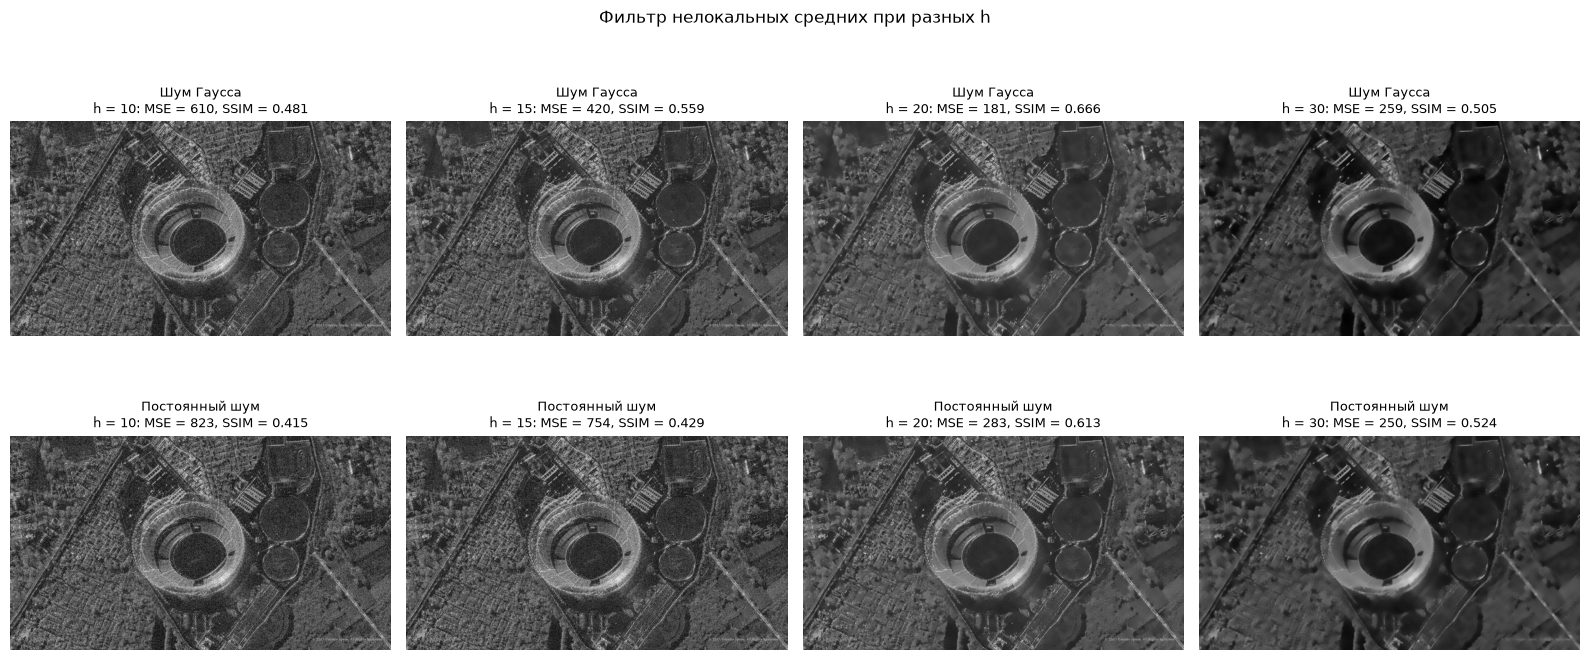

In [15]:
plot_grid(nlm_gauss, nlm_unif, 'Фильтр нелокальных средних при разных h')

## Сравнение

In [16]:
for noise_name, noisy_ssim in [('Шум Гаусса', ssim_noise_gauss), ('Постоянный шум', ssim_noise_unif)]:
    print('=' * 22, noise_name, '(SSIM без фильтрации = %.4f)' % noisy_ssim, '=' * 22)
    rows = sorted([r for r in results if r[0] == noise_name], key=lambda r: r[3], reverse=True)
    print('%-36s %10s %8s' % ('Фильтр', 'MSE', 'SSIM'))
    for _, filter_name, mse, ssim in rows:
        print('%-36s %10.1f %8.4f' % (filter_name, mse, ssim))
    best_mse = min(rows, key=lambda r: r[2])
    best_ssim = max(rows, key=lambda r: r[3])
    print()
    print('Лучший по MSE:  %s (MSE = %.1f)' % (best_mse[1], best_mse[2]))
    print('Лучший по SSIM: %s (SSIM = %.4f)' % (best_ssim[1], best_ssim[3]))
    print()

====================== Шум Гаусса (SSIM без фильтрации = 0.4810) ======================
Фильтр                                      MSE     SSIM
Фильтр Гаусса (k = 3)                     150.3   0.7239
Фильтр Гаусса (k = 5)                     156.8   0.7061
Билатериальный (d = 5, sigma = 50)        163.0   0.7034
Нелокальных средних (h = 20)              181.4   0.6659
Фильтр Гаусса (k = 7)                     189.0   0.6477
Медианный (k = 3)                         210.6   0.6364
Билатериальный (d = 9, sigma = 75)        202.1   0.6124
Билатериальный (d = 5, sigma = 25)        302.9   0.6031
Фильтр Гаусса (k = 9)                     214.8   0.6017
Медианный (k = 5)                         240.5   0.5603
Нелокальных средних (h = 15)              420.5   0.5592
Билатериальный (d = 9, sigma = 150)       253.3   0.5279
Нелокальных средних (h = 30)              259.5   0.5052
Медианный (k = 7)                         286.0   0.4819
Нелокальных средних (h = 10)              610.1   0.4810


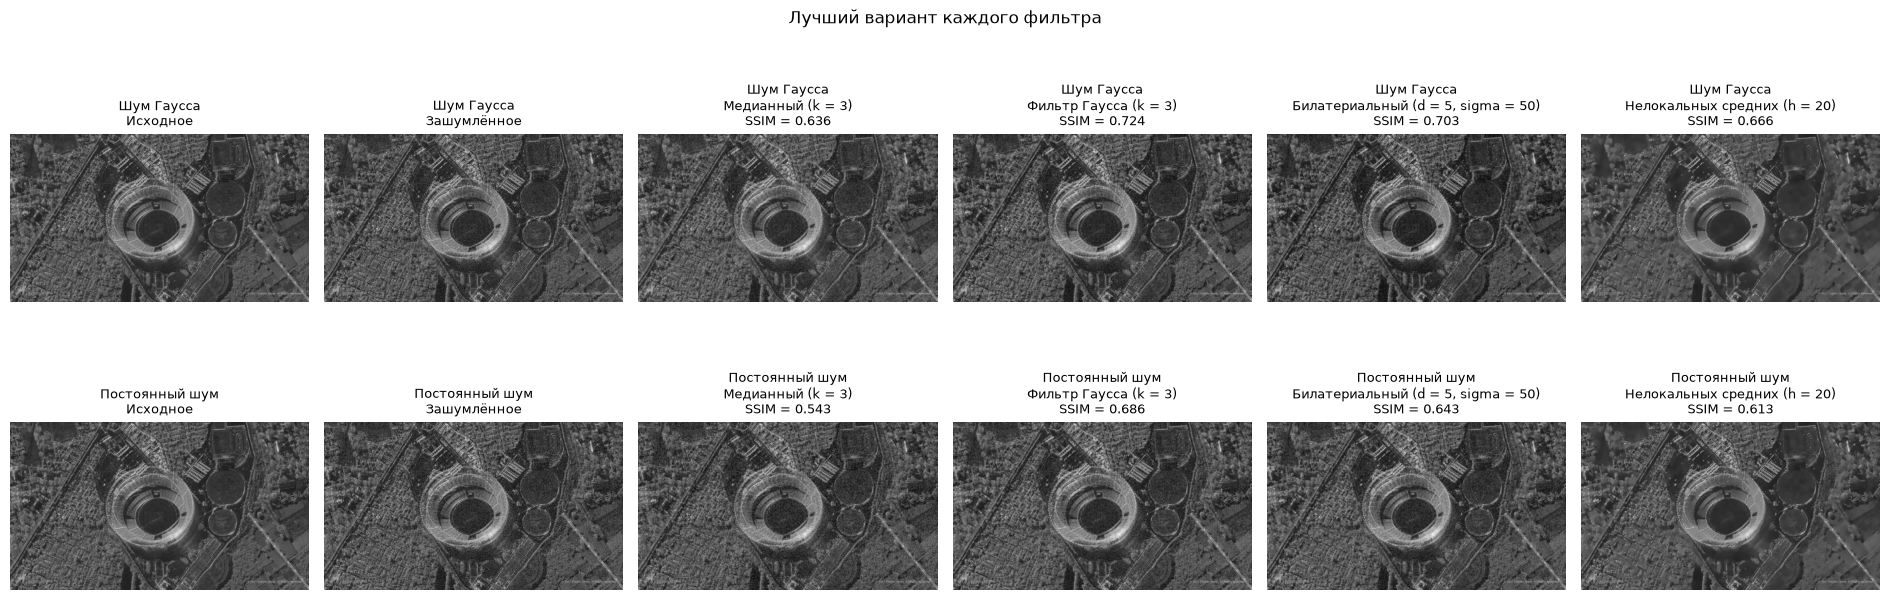

In [17]:
# лучший (по SSIM) вариант каждого фильтра
filter_groups = ['Медианный', 'Фильтр Гаусса', 'Билатериальный', 'Нелокальных средних']

plt.figure(figsize=(19, 7))
row = 0
for noise_name, noisy_img in [('Шум Гаусса', image_noise_gauss), ('Постоянный шум', image_noise_unif)]:
    columns = [('Исходное', image_gray), ('Зашумлённое', noisy_img)]
    for group in filter_groups:
        candidates = [r for r in results if r[0] == noise_name and r[1].startswith(group)]
        best = max(candidates, key=lambda r: r[3])
        columns.append((best[1] + '\nSSIM = %.3f' % best[3], images[(noise_name, best[1])]))

    for col, (title, img) in enumerate(columns):
        plt.subplot(2, len(columns), row * len(columns) + col + 1)
        plt.imshow(img, cmap='gray')
        plt.title('%s\n%s' % (noise_name, title), fontsize=9)
        plt.axis('off')
    row += 1

plt.suptitle('Лучший вариант каждого фильтра')
plt.tight_layout()
plt.show()
